In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.font_manager as fm
import itertools

from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from itertools import combinations
from collections import Counter
import community as community_louvain

In [4]:
games = pd.read_csv('games.csv')
characters = pd.read_csv("characters.csv")
gameAppearance = pd.read_csv("gameAppearance.csv")
interactions = pd.read_csv("interactions.csv")
scenes = pd.read_csv("scenes.csv")

In [5]:
gameAppearance[gameAppearance["game_id"] == "re3"]

,game_id,character_id,role,game_title,character_name
28,re3,16,hero,Resident Evil 3: Nemesis,Jill Valentine
29,re3,18,support,Resident Evil 3: Nemesis,Brad Vickers
30,re3,30,support,Resident Evil 3: Nemesis,Marvin Branagh
31,re3,33,hero,Resident Evil 3: Nemesis,Carlos Oliveira
32,re3,34,villain,Resident Evil 3: Nemesis,Nemesis
33,re3,35,villain,Resident Evil 3: Nemesis,Nikolai Zinoviev
34,re3,36,support,Resident Evil 3: Nemesis,Mikhail Victor
35,re3,37,support,Resident Evil 3: Nemesis,Dario Rosso


In [8]:
border_subtle = "#2d333b"
accent       = "#3ecf8e"
accent_dark = "#1f7f54"
villain = "#e5534b"
background = "#0d1117"
def set_sns_style():
    bg_page      = "#0d1117"
    bg_card      = "#161b22"
    text_primary = "#e6edf3"
    text_muted   = "#8b949e"

    sns.set_theme(style="whitegrid")
    sns.set_style({
        "axes.facecolor": bg_card,
        "figure.facecolor": bg_page,
        "axes.edgecolor": border_subtle,
        "axes.spines.right": False,
        "axes.spines.top": False,
        "grid.color": border_subtle,
        "grid.linestyle": "-",
        "grid.linewidth": 0.5,
    })
    sns.set_palette([accent, accent_dark])

    plt.rcParams.update({
        "figure.facecolor": bg_page,
        "axes.facecolor": bg_card,
        "axes.titlesize": 14,
        "axes.labelsize": 11,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "text.color": text_primary,
        "axes.labelcolor": text_primary,
        "xtick.color": text_muted,
        "ytick.color": text_muted,
        "font.family": "Inter 18pt",#"sans-serif",
        "font.sans-serif": [
            "Inter",
            "system-ui",
            "-apple-system",
            "BlinkMacSystemFont",
            "Segoe UI",
            "DejaVu Sans",
        ],
    })

set_sns_style()

findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt'

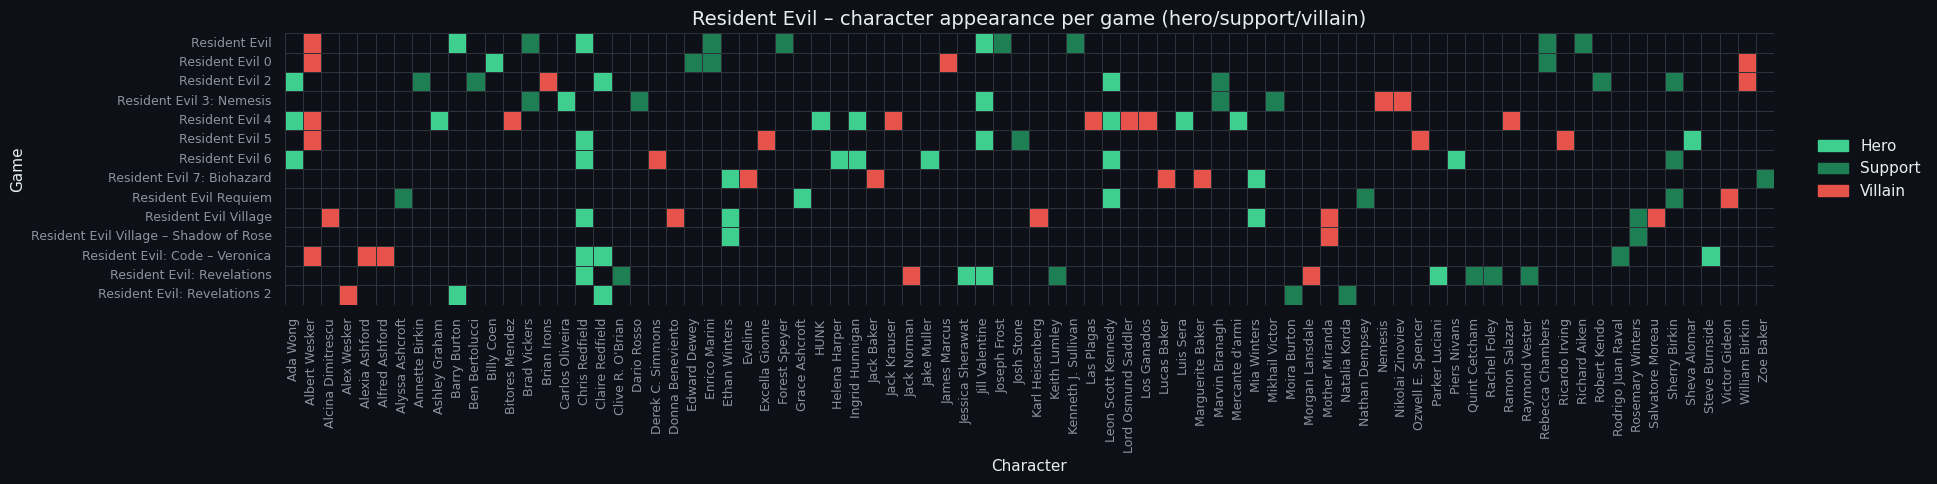

In [9]:
games_small = games[['id','title']].rename(columns={'id': 'game_id'})
chars_small = characters[['id','name']].rename(columns={'id': 'character_id'})

pairs = (
    gameAppearance[['game_id', 'character_id']]
    .drop_duplicates()
)

pairs =(
    pairs
    .merge(games_small, on='game_id', how='left')
    .merge(chars_small, on='character_id', how='left')
)
pairs['presence'] = 1

heatmap_df = pairs.pivot_table(
    index='title',      
    columns='name',     
    values='presence',
    fill_value=0
)

chars_with_role = characters[['name', 'role']].drop_duplicates()
roles = chars_with_role.set_index('name').reindex(heatmap_df.columns)['role']

values = heatmap_df.values 
val_matrix = np.zeros_like(values, dtype=int)

role_mask_hero    = (roles == 'hero').values
role_mask_support = (roles == 'support').values
role_mask_villain = (roles == 'villain').values

val_matrix[(values == 1) & (role_mask_hero[np.newaxis, :])] = 1
val_matrix[(values == 1) & (role_mask_support[np.newaxis, :])] = 2
val_matrix[(values == 1) & (role_mask_villain[np.newaxis, :])] = 3

bg      = background
hero_c  = accent       
supp_c  = accent_dark   
vill_c  = villain     

cmap_roles = ListedColormap([bg, hero_c, supp_c, vill_c])

plt.figure(figsize=(18, 5))
ax = sns.heatmap(
    val_matrix,
    cmap=cmap_roles,
    cbar=False,
    linewidths=.5,
    linecolor=border_subtle,
    xticklabels=heatmap_df.columns,
    yticklabels=heatmap_df.index
)
plt.title("Resident Evil – character appearance per game (hero/support/villain)")
plt.xlabel("Character")
plt.ylabel("Game")
plt.tight_layout()

hero_patch    = mpatches.Patch(color=hero_c,  label="Hero")
support_patch = mpatches.Patch(color=supp_c,  label="Support")
villain_patch = mpatches.Patch(color=vill_c,  label="Villain")

plt.legend(
    handles=[hero_patch, support_patch, villain_patch],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),  
    frameon=False
)
plt.show()

In this image we can see a matrix where each row is a game, and each column is a character, the color indicate weather the character is a hero, support, or villain.

Most of the squares are clearly empty and only a few characters appear in more than 2 games.

The roles of the characters stays consistent throughout the games.

findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt'

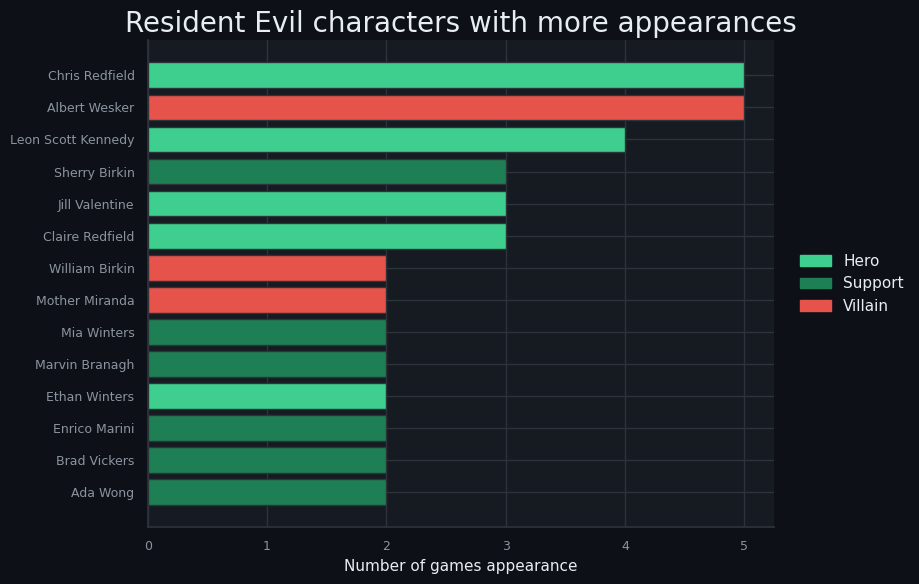

In [10]:
char_games = (
    gameAppearance[["character_name", "game_id", "role"]]
    .drop_duplicates()
    .groupby(["character_name", "role"])["game_id"]
    .nunique()
    .reset_index(name="n_games")
)

char_games = char_games[char_games["n_games"] > 1]
plot_df = char_games.sort_values("n_games", ascending=True)

def role_to_color(role):
    if role == "hero":
        return accent            
    elif role == "support":
        return accent_dark         
    elif role == "villain":
        return villain          
    else:
        return accent_dark         

colors = [role_to_color(r) for r in plot_df["role"]]


plt.figure(figsize=(8, 6))
plt.barh(
    plot_df["character_name"],
    plot_df["n_games"],
    color=colors,
    edgecolor=border_subtle,
)
plt.xlabel("Number of games appearance")
plt.ylabel("")
plt.title("Resident Evil characters with more appearances", fontsize=20)
plt.tight_layout()
hero_patch    = mpatches.Patch(color=accent,      label="Hero")
support_patch = mpatches.Patch(color=accent_dark, label="Support")
villain_patch = mpatches.Patch(color=villain,     label="Villain")

plt.legend(
    handles=[hero_patch, support_patch, villain_patch],
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False,
)

plt.show()

In [11]:
def plot_ego_bar(char_id, top_n=15, ax=None):
    scenes = interactions.loc[
        interactions["character_id"] == char_id, "scene_id"
    ].unique()

    sub = interactions[
        interactions["scene_id"].isin(scenes)
        & (interactions["character_id"] != char_id)
    ]

    counts = (
        sub[["scene_id", "character_id"]]
        .drop_duplicates()
        ["character_id"]
        .value_counts()
        .reset_index()
    )

    counts.columns = ["target", "weight"]

    ego_edges = (
        counts
        .merge(characters[["id", "name", "role"]], 
               left_on="target", right_on="id", how="left")
        .sort_values("weight", ascending=False)
    )

    plot_df = ego_edges.head(top_n)

    if ax is None:
        ax = plt.gca()

    barplot = sns.barplot(
        data=plot_df,
        y="name",
        x="weight",
        color=accent_dark,         
        edgecolor=border_subtle,
        ax=ax,
    )

    for bar, role in zip(barplot.patches, plot_df["role"]):
        if role == "hero":
            bar.set_facecolor(accent)        
        elif role == "support":
            bar.set_facecolor(accent_dark)   
        elif role == "villain":
            bar.set_facecolor(villain)     

    char_name = characters.loc[characters["id"] == char_id, "name"].iloc[0]
    ax.set_xlabel("Scenes shared")
    ax.set_ylabel("")
    ax.set_title(f"{char_name} – top co-occurrences")

findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt'

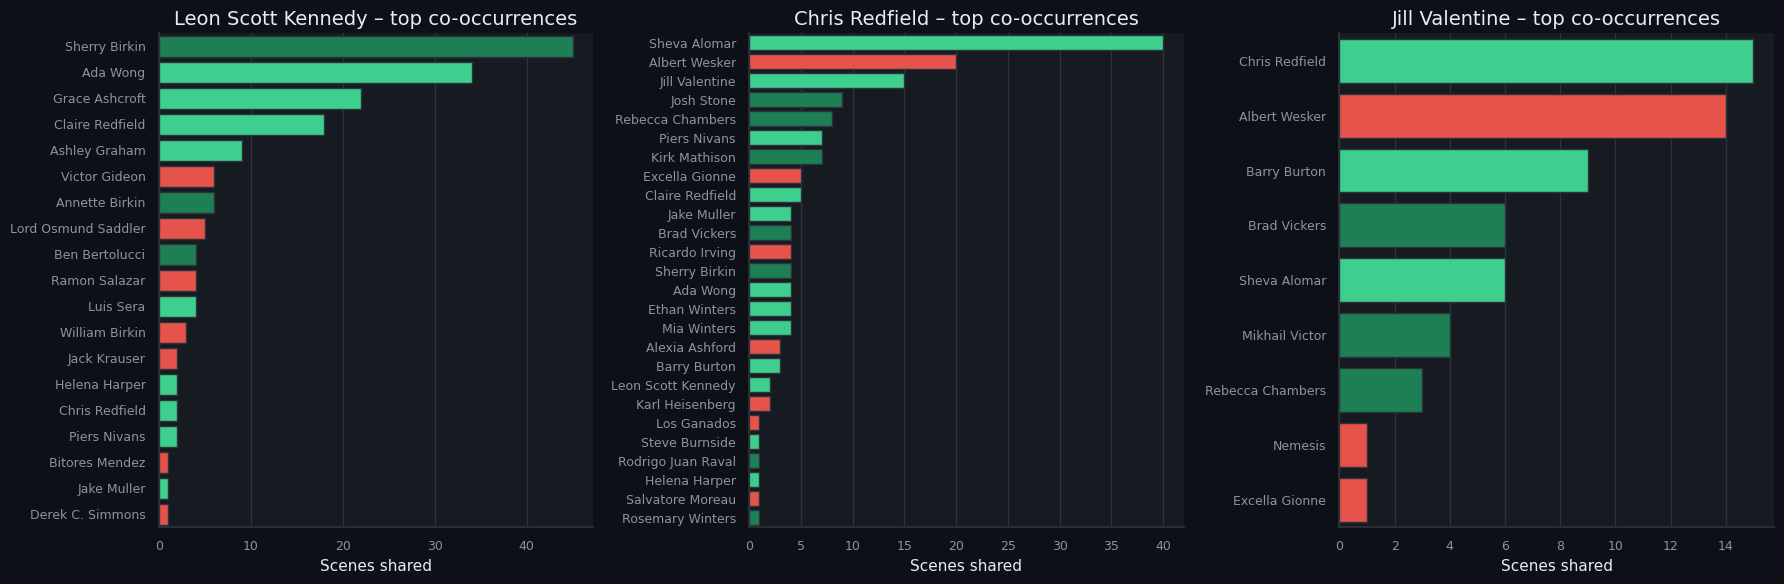

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharex=False)

for char_id, ax in zip([1, 15, 16], axes):
    plot_ego_bar(char_id, top_n=35, ax=ax)
plt.tight_layout()
plt.show()

Now, this three bar charts show the characters with the most shared scenes with Leon, Chris and Jill. Leon shares the most scenes with Sherry, followed by Ada, Grace and Claire, not many scenes with Ashley though. Remember we are considering cutscenes only, not the gameplay. As for Chris, he seems to shere too many scenes with Sheva, which could be realistic since they've been together throughout the entire Resident Evil 5. Jill appeared most of the scenes with Chris and the villain Albert Wesker, followed by her S.T.A.R.S. teammate Barry Burton.

In [13]:
game_ids = ["re_re", "re_re2"]
gameAppearance = gameAppearance[~gameAppearance["game_id"].isin(game_ids)]

In [18]:
MIN_WEIGHT = 0

scene_chars = (
    interactions
    .groupby(["game_id", "scene_id"])["character_id"]
    .apply(lambda ids: list(set(ids)))
    .reset_index(name="chars")
)

edge_counter = Counter()

for _, row in scene_chars.iterrows():
    chars = row["chars"]
    for c1, c2 in itertools.combinations(sorted(chars), 2):
        edge_counter[(int(c1), int(c2))] += 1

edges_df = (
    pd.DataFrame(
        [(s, t, w) for (s, t), w in edge_counter.items()],
        columns=["source", "target", "weight"]
    )
)

G = nx.Graph()

for _, row in edges_df.iterrows():
    if row["weight"] >= MIN_WEIGHT:       
        G.add_edge(
            int(row["source"]),
            int(row["target"]),
            weight=int(row["weight"])
        )
print(f"Diameter: {nx.diameter(G)}")
print(f"Density {nx.density(G)}")
print(f"Average shortest path: {nx.average_shortest_path_length(G)}")
print(f"Average clustering: {nx.average_clustering(G)}")
print(f"Transitivity: {nx.transitivity(G)}")

Diameter: 5
Density 0.10901960784313726
Average shortest path: 2.552156862745098
Average clustering: 0.7214828205849879
Transitivity: 0.41897940913160253


After plotting a basic graph we can see some of its metrics. The diameter of the graph is 5, which means that each character needs at most 5 steps to reach any other, with an average of 2.55 steps (a typical example of the small-world phenomenon). A density of 0.11 means that the graph is quite sparse, but still well-connected. The average clustering is pretty high at 0.72, this metric shows how many neighbours of a node tend to be connected. Transitivity has a more global perspective compared to the average clustering, 42% of connected triples are closed into triangles, still a high value for the triadic closure, but lower than suggested by the local clustering. The transitivity has less sensitivity to low degree nodes than the average clustering metric has.

In [19]:
deg_c  = nx.degree_centrality(G)
bet_c  = nx.betweenness_centrality(G, normalized=True)
clo_c  = nx.closeness_centrality(G)
eig_c  = nx.eigenvector_centrality(G, max_iter=200)
prk_c = nx.pagerank(G, alpha=0.85)

id_to_name = characters.set_index("id")["name"].to_dict()

def top_n_from_dict(d, n=10):
    return sorted(d.items(), key=lambda x: x[1], reverse=True)[:n]

top10_degree     = top_n_from_dict(deg_c, 10)
top10_betweenness = top_n_from_dict(bet_c, 10)
top10_closeness   = top_n_from_dict(clo_c, 10)
top10_eigenvector = top_n_from_dict(eig_c, 10)
top10_pageRank = top_n_from_dict(prk_c, 10)

print("Top 10 – Degree centrality")
for node, val in top10_degree:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")

print("\nTop 10 – Betweenness centrality")
for node, val in top10_betweenness:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")

print("\nTop 10 – Closeness centrality")
for node, val in top10_closeness:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")

print("\nTop 10 – Eigenvector centrality")
for node, val in top10_eigenvector:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")
    
print("\nTop 10 – Page Rank")
for node, val in top10_pageRank:
    print(f"{id_to_name.get(node, node)}: {val:.4f}")

Top 10 – Degree centrality
Chris Redfield: 0.5200
Leon Scott Kennedy: 0.3800
Ada Wong: 0.2800
Claire Redfield: 0.2200
Sherry Birkin: 0.2000
Albert Wesker: 0.1800
Jill Valentine: 0.1800
Rebecca Chambers: 0.1600
Sheva Alomar: 0.1600
Ethan Winters: 0.1600

Top 10 – Betweenness centrality
Chris Redfield: 0.6519
Leon Scott Kennedy: 0.2846
Rebecca Chambers: 0.1518
Ada Wong: 0.0890
Claire Redfield: 0.0673
Jill Valentine: 0.0654
Grace Ashcroft: 0.0531
Ethan Winters: 0.0526
Rosemary Winters: 0.0421
Karl Heisenberg: 0.0293

Top 10 – Closeness centrality
Chris Redfield: 0.6667
Leon Scott Kennedy: 0.5556
Ada Wong: 0.5155
Claire Redfield: 0.5000
Sherry Birkin: 0.4950
Jake Muller: 0.4762
Helena Harper: 0.4762
Piers Nivans: 0.4717
Albert Wesker: 0.4673
Jill Valentine: 0.4545

Top 10 – Eigenvector centrality
Chris Redfield: 0.4060
Leon Scott Kennedy: 0.3614
Ada Wong: 0.3243
Sherry Birkin: 0.2753
Claire Redfield: 0.2467
Jake Muller: 0.2182
Helena Harper: 0.2182
Piers Nivans: 0.2057
Albert Wesker: 0.158

Now, let's talk a bit about the difference centrality metrics. Centrality measures how important a node is in the network. Degree centrality simply counts how many connections each node has, the biggest nodes are the ones with the most connections (in case of weighted graphs, we can sum the strength of the edges). The values we got are normalised, Chris having a degree centrality of 0.52 means that he is connected with 52% of the nodes. Betweenness centrality is a little more tricky, it measures how often a node lies on shortest paths, characters with a high value of betweenness are the bridges of the graph that connects different part of the network. Chris has even more betweenness centrality, and compared with the degree centrality, he lies on more than 65% of shortest paths. In the graph we'll visualize later we will see that the network is divided in clusters, with Chris often being the bridge between them, explaining the high values in betweenness centrality. Closeness is the inverse of the sum of the distance between a node and all the others, Characters with high closeness are close to the other characters, there isn't a character that Chris cannot reach in two or fewer jumps, hence his high closeness. The next metric of centrality is the Eigenvector, it rewards nodes that are connected with high centrality nodes. Chris is, again, the one with the highest eigenvector centrality, making him the most influential node. Having lots of connection with peripheral nodes doesn't contribute much to eigenvector centrality. The formula for the eigenvector centrality uses a matrix of adjacency (0/1 for non weighted graphs, otherwise the strength of the edges) and the eigenvalues. Finally, PageRank was created for search engines and is similar to the Eigenvector centrality. Besides who a node is connected to, it also takes into account a damping factor to normalise the value (ensuring that every node has a possibility of being viewed). Leon, the highest in PageRank, he is a key character connected with the most influential ones (Chris, Ada, Claire, Jill,...). Chris and Leon are the ones that dominates throughout the metrics (always the top 2).

findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt'

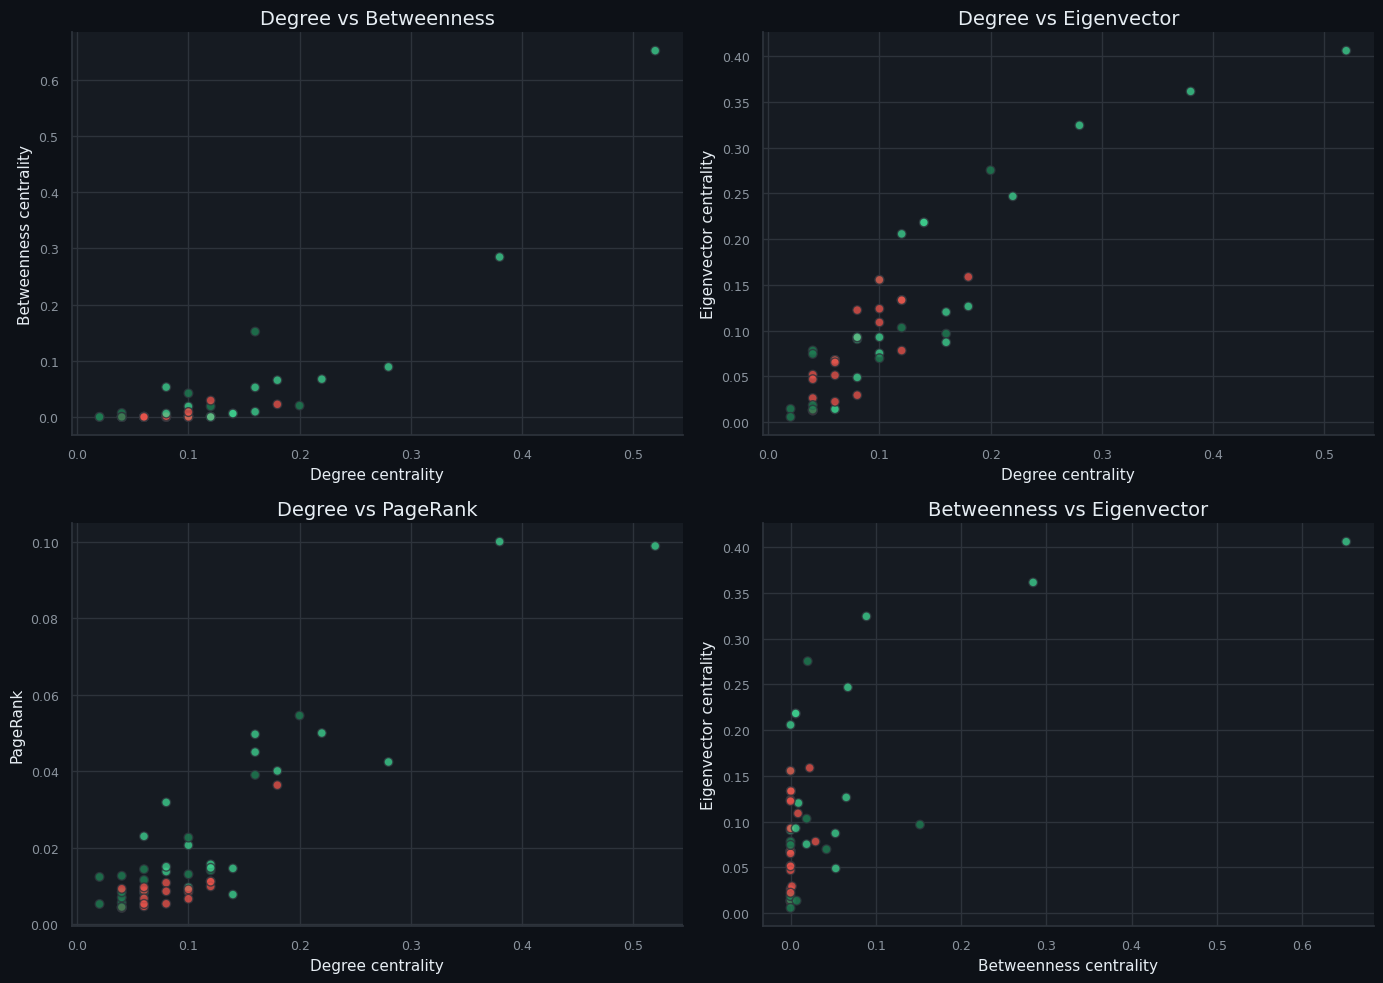

In [20]:
cent_df = (
    pd.DataFrame({
        "id": list(G.nodes()),
        "degree": [deg_c[n] for n in G.nodes()],
        "betweenness": [bet_c[n] for n in G.nodes()],
        "closeness": [clo_c[n] for n in G.nodes()],
        "eigenvector": [eig_c[n] for n in G.nodes()],
        "pagerank": [prk_c[n] for n in G.nodes()],
    })
    .merge(characters[["id", "name", "role"]], on="id", how="left")
)

cent_df["color"] = cent_df["role"].apply(role_to_color)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].scatter(
    cent_df["degree"], cent_df["betweenness"],
    c=cent_df["color"], edgecolor=border_subtle, alpha=0.8, s=40,
)
axes[0, 0].set_xlabel("Degree centrality")
axes[0, 0].set_ylabel("Betweenness centrality")
axes[0, 0].set_title("Degree vs Betweenness")

axes[0, 1].scatter(
    cent_df["degree"], cent_df["eigenvector"],
    c=cent_df["color"], edgecolor=border_subtle, alpha=0.8, s=40,
)
axes[0, 1].set_xlabel("Degree centrality")
axes[0, 1].set_ylabel("Eigenvector centrality")
axes[0, 1].set_title("Degree vs Eigenvector")

axes[1, 0].scatter(
    cent_df["degree"], cent_df["pagerank"],
    c=cent_df["color"], edgecolor=border_subtle, alpha=0.8, s=40,
)
axes[1, 0].set_xlabel("Degree centrality")
axes[1, 0].set_ylabel("PageRank")
axes[1, 0].set_title("Degree vs PageRank")

axes[1, 1].scatter(
    cent_df["betweenness"], cent_df["eigenvector"],
    c=cent_df["color"], edgecolor=border_subtle, alpha=0.8, s=40,
)
axes[1, 1].set_xlabel("Betweenness centrality")
axes[1, 1].set_ylabel("Eigenvector centrality")
axes[1, 1].set_title("Betweenness vs Eigenvector")

plt.tight_layout()
plt.show()

These scatter plots compare different centrality measures for each character. Degree, Eigenvector, and PageRank show a strong positive relationship, meaning that characters with many connections tend to be linked to other influential ones. In contrast, Betweenness looks more skewed and characters like Chris and Leon act as major bridges, most of the other characters have very low betweenness centrality (<0.1).

I want to specify that all the centrality values are normalized (scaled between 0 and 1) to ensure a correct comparison.

findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt'

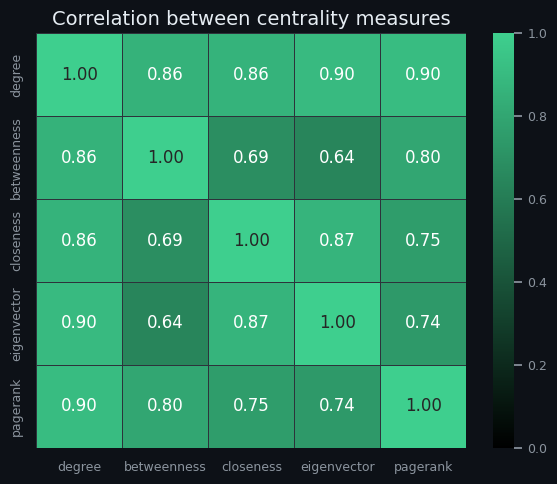

In [21]:
corr = cent_df[["degree", "betweenness", "closeness", "eigenvector", "pagerank"]].corr()

cm_corr = LinearSegmentedColormap.from_list(
    "re_corr",
    ["#000000", accent]   
)

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=cm_corr,
    vmin=0,
    vmax=1,
    linewidths=.5,
    linecolor=border_subtle
)
plt.title("Correlation between centrality measures")
plt.tight_layout()
plt.show()

In [22]:
for col in ["degree", "betweenness", "closeness", "eigenvector"]:
    rank_col = col + "_rank"
    cent_df[rank_col] = cent_df[col].rank(ascending=False, method="min")

cent_df["total_rank"] = (
    cent_df["degree_rank"]
    + cent_df["betweenness_rank"]
    + cent_df["closeness_rank"]
    + cent_df["eigenvector_rank"]
)
cent_df["mean_rank"] = cent_df["total_rank"] / 4

top_mask = (
    (cent_df["degree_rank"] <= 10) |
    (cent_df["betweenness_rank"] <= 10) |
    (cent_df["closeness_rank"] <= 10) |
    (cent_df["eigenvector_rank"] <= 10)
)

rank_table = (
    cent_df.loc[
        top_mask,
        [
            "name",
            "role",
            "degree_rank",
            "betweenness_rank",
            "closeness_rank",
            "eigenvector_rank",
            "total_rank",
            "mean_rank",
        ],
    ]
    .sort_values("total_rank")
    .reset_index(drop=True)
)

rank_table

,name,role,degree_rank,betweenness_rank,closeness_rank,eigenvector_rank,total_rank,mean_rank
0,Chris Redfield,hero,1.0,1.0,1.0,1.0,4.0,1.00
1,Leon Scott Kennedy,hero,2.0,2.0,2.0,2.0,8.0,2.00
2,Ada Wong,hero,3.0,4.0,3.0,3.0,13.0,3.25
3,Claire Redfield,hero,4.0,5.0,4.0,5.0,18.0,4.50
4,Sherry Birkin,support,5.0,12.0,5.0,4.0,26.0,6.50
5,Albert Wesker,villain,6.0,11.0,9.0,9.0,35.0,8.75
6,Jill Valentine,hero,6.0,6.0,10.0,15.0,37.0,9.25
7,Jake Muller,hero,11.0,19.0,6.0,6.0,42.0,10.50
8,Rebecca Chambers,support,8.0,3.0,11.0,21.0,43.0,10.75
9,Helena Harper,hero,11.0,19.0,6.0,7.0,43.0,10.75


findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt'

Number of characters per role:
role
villain    31
support    29
hero       23
Name: count, dtype: int64

Mixing matrix:
[[0.23741007 0.11870504 0.16906475]
 [0.11870504 0.04316547 0.03597122]
 [0.16906475 0.03597122 0.07194245]]


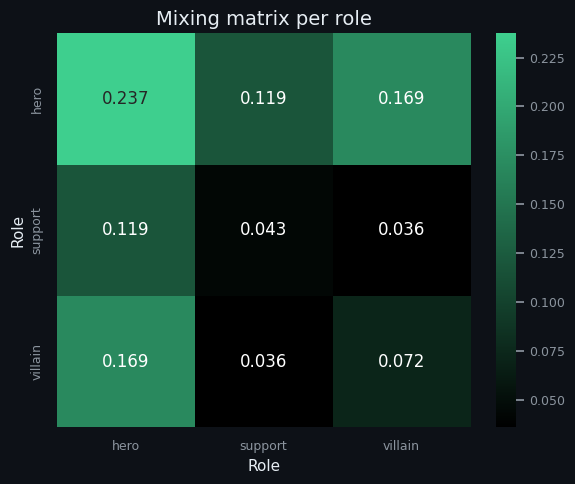

In [23]:
role_dict = characters.set_index("id")["role"].to_dict()

nx.set_node_attributes(G, role_dict, "role")

roles_unique = sorted(set(role_dict.values()))
role_to_idx = {r: i for i, r in enumerate(roles_unique)}

mix = nx.attribute_mixing_matrix(
    G,
    attribute="role",
    mapping=role_to_idx,
    normalized=True,
)


role_counts = characters["role"].value_counts()
print("Number of characters per role:")
print(role_counts)

print("\nMixing matrix:")
print(mix)

plt.figure(figsize=(6, 5))
sns.heatmap(
    mix,
    annot=True,
    fmt=".3f",
    xticklabels=roles_unique,
    yticklabels=roles_unique,
    cmap=cm_corr,
)
plt.xlabel("Role")
plt.ylabel("Role")
plt.title("Mixing matrix per role")
plt.tight_layout()
plt.show()

In [24]:
cliques = list(nx.find_cliques(G)) 

print(f"Numer of cliques: {len(cliques)}")

cliques_k = [c for c in cliques if len(c) >= 3]

print(f"Numer of cliques with at least 3 characters: {len(cliques_k)}")

N = 10
cliques_k_sorted = sorted(cliques_k, key=len, reverse=True)[:N]

for i, clique in enumerate(cliques_k_sorted, start=1):
    names = [id_to_name.get(n, str(n)) for n in clique]
    print(f"Clique #{i} (size={len(clique)}): {', '.join(names)}")

Numer of cliques: 32
Numer of cliques with at least 3 characters: 28
Clique #1 (size=7): Chris Redfield, Leon Scott Kennedy, Ada Wong, Sherry Birkin, Jake Muller, Helena Harper, Piers Nivans
Clique #2 (size=6): Ashley Graham, Leon Scott Kennedy, Lord Osmund Saddler, Ramon Salazar, Ada Wong, Jack Krauser
Clique #3 (size=6): William Birkin, Leon Scott Kennedy, Claire Redfield, Sherry Birkin, Ada Wong, Annette Birkin
Clique #4 (size=5): Ashley Graham, Leon Scott Kennedy, Lord Osmund Saddler, Ramon Salazar, Luis Sera
Clique #5 (size=5): Chris Redfield, Leon Scott Kennedy, Ada Wong, Sherry Birkin, Claire Redfield
Clique #6 (size=5): Chris Redfield, Albert Wesker, Jill Valentine, Brad Vickers, Barry Burton
Clique #7 (size=5): Chris Redfield, Albert Wesker, Jill Valentine, Brad Vickers, Rebecca Chambers
Clique #8 (size=5): Chris Redfield, Albert Wesker, Jill Valentine, Sheva Alomar, Excella Gionne
Clique #9 (size=5): Derek C. Simmons, Leon Scott Kennedy, Sherry Birkin, Jake Muller, Helena Har

In [25]:
id_to_role = characters.set_index("id")["role"].to_dict()

def triad_role_type(u, v, w):
    roles = sorted([id_to_role.get(u), id_to_role.get(v), id_to_role.get(w)])
    return tuple(roles) 

motif_counts = Counter()

for u, v, w in combinations(G.nodes(), 3):
    if G.has_edge(u, v) and G.has_edge(u, w) and G.has_edge(v, w):
        motif_counts[triad_role_type(u, v, w)] += 1

print("Motif of triads per role (only cliques with at least 3 characters):")
for roles, cnt in motif_counts.most_common():
    print(f"{roles}: {cnt}")

Motif of triads per role (only cliques with at least 3 characters):
('hero', 'hero', 'villain'): 40
('hero', 'hero', 'support'): 33
('hero', 'hero', 'hero'): 29
('hero', 'villain', 'villain'): 22
('hero', 'support', 'villain'): 21
('hero', 'support', 'support'): 6
('support', 'support', 'villain'): 2
('villain', 'villain', 'villain'): 2
('support', 'support', 'support'): 1


findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt' not found.
findfont: Font family 'Inter 18pt'

Grafo: 49 nodi, 137 archi


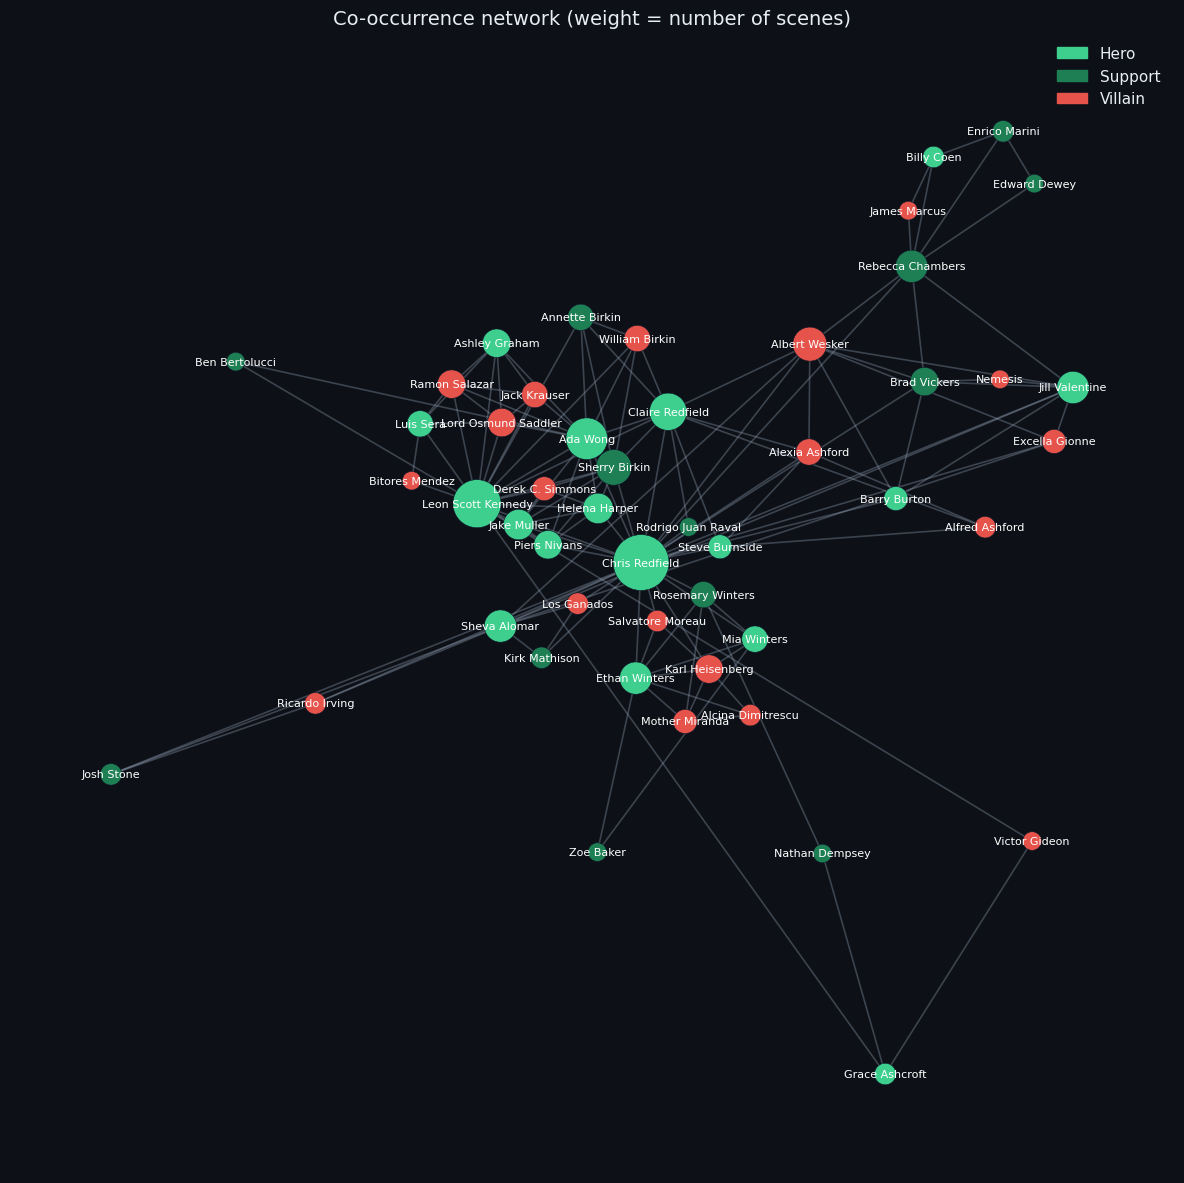

In [26]:
isolated_nodes = list(nx.isolates(G))
G.remove_nodes_from(isolated_nodes)

degree_dict = dict(G.degree())
nodes_deg1 = [n for n, d in degree_dict.items() if d == 1]
G.remove_nodes_from(nodes_deg1)

print(f"Grafo: {G.number_of_nodes()} nodi, {G.number_of_edges()} archi")

degree_dict = dict(G.degree())

plt.figure(figsize=(12, 12))
pos = nx.kamada_kawai_layout(G)

nx.draw_networkx_edges(
    G, pos,
    alpha=0.35,
    width=1.2,
    edge_color="#94a3b8"
)

node_sizes = [60 + 60 * degree_dict[n] for n in G.nodes()]

color_map = {
    "hero":    accent,
    "support": accent_dark,
    "villain": villain
}
node_colors = [
    color_map.get(id_to_role.get(n), accent_dark)
    for n in G.nodes()
]

nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edgecolors="#0f172a",
    linewidths=0.4
)


top_nodes = sorted(degree_dict, key=degree_dict.get, reverse=True)[:90]
top_nodes = [n for n in top_nodes if n in G]  
labels = {n: id_to_name.get(n, str(n)) for n in top_nodes}

nx.draw_networkx_labels(
    G, pos,
    labels=labels,
    font_size=8,
    font_color="white"
)


for n in G.nodes():
    G.nodes[n]["label"] = id_to_name.get(n, str(n))      
    G.nodes[n]["role"] = id_to_role.get(n, "unknown")
    G.nodes[n]["degree"] = degree_dict.get(n, 0)

nx.write_gexf(G, "co_occurrence.gexf")

plt.axis("off")
plt.title("Co-occurrence network (weight = number of scenes)")

hero_patch    = mpatches.Patch(color=accent,      label="Hero")
support_patch = mpatches.Patch(color=accent_dark, label="Support")
villain_patch = mpatches.Patch(color=villain,     label="Villain")

plt.legend(
    handles=[hero_patch, support_patch, villain_patch],
    loc="upper right",
    frameon=False
)

plt.tight_layout()
plt.show()